# **Customer Churn**

# **1. Importar las librerías**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings('ignore')

# **2. Importar conjunto de datos**

In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Es un problema de clasificación, donde se analiza si un cliente ha dejado o no una compañia.

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

* **CustomerID**: Un ID único que identifica a cada cliente.
* **Gender**: El género del cliente: Male, Femenino.
* **Senior Citizen**: Indica si el cliente tiene 65 años o más: Yes, No.
* **Partner**: Indica si el cliente está casado: Yes, No.
* **Dependents**: Indica si el cliente vive con alguna persona dependiente: Yes, No. Los dependientes pueden ser hijos, padres, abuelos, etc.
* **Tenure**: Indica la cantidad total de meses que el cliente ha estado con la compañía al final del trimestre especificado anteriormente.
* **Phone Service**: Indica si el cliente está suscrito al servicio de telefonía residencial con la compañía: Yes, No.
* **Multiple Lines**: Indica si el cliente está suscrito a múltiples líneas telefónicas con la compañía: Yes, No.
* **Internet Service**: Indica si el cliente está suscrito al servicio de Internet con la compañía: No, DSL, Fiber Optic, Cable.
* **Online Security**: Indica si el cliente está suscrito a un servicio adicional de seguridad en línea proporcionado por la compañía: Yes, No.
* **Online Backup**: Indica si el cliente está suscrito a un servicio adicional de copia de seguridad en línea proporcionado por la compañía: Yes, No.
* **Device Protection**: Indica si el cliente está suscrito a un plan adicional de protección de dispositivos para su equipo de Internet proporcionado por la compañía: Yes, No.
* **TechSupport**: Indica si el cliente está suscrito a un plan adicional de soporte técnico de la compañía con tiempos de espera reducidos: Sí, No.
* **Streaming TV**: Indica si el cliente utiliza su servicio de Internet para transmitir programación de televisión de un proveedor externo: Yes, No. La compañía no cobra un cargo adicional por este servicio.
* **Streaming Movies**: Indica si el cliente utiliza su servicio de Internet para transmitir películas de un proveedor externo: Yes, No. La compañía no cobra un cargo adicional por este servicio.
* **Contract**: Indica el tipo de contrato actual del cliente: Mes a mes (Month-to-Month), un año (One Year), dos años (Two Year).
* **Paperless Billing**: Indica si el cliente ha elegido la facturación sin papel: Yes, No.
* **Payment Method**: Indica el método de pago preferido del cliente: Cheque electrónico (Electronic check), cheque enviado por correo (Mailed check), transferencia bancaria (Bank transfer), tarjeta de crédito (Credit card).
* **Monthly Charge**: Indica el cargo mensual total actual del cliente por todos sus servicios con la compañía.
* **Total Charges**: Indica los cargos totales del cliente, calculados hasta el final del trimestre especificado anteriormente.
* **Churn**: Yes = el cliente dejó la compañía este trimestre. No = el cliente permaneció en la compañía.


# **3. EDA**

In [ ]:
df.shape

(7043, 21)

Hay 7043 registros y 21 variables

## 3.1 Comprobar el tipo de dato de cada columna

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


La variable "TotalCharges" debería ser numérica pero es de tipo object.

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

## 3.2 Eliminar columnas irrelevantes

Eliminaré la columna 'customerID' ya que no proporciona información relevante para el análisis

In [ ]:
df.drop(columns=['customerID'], inplace=True)

## 3.3 Tipo de variables

En esta sección, separaré entre variables categóricas y numéricas. Las variables categóricas son de tipo object y las numéricas de tipo float64 o int64.

In [ ]:
categorical = [var for var in df.columns if df[var].dtype == 'object']
numerical = [var for var in df.columns if df[var].dtype != 'object']
print('Las variables categóricas son: ', categorical)
print('Las variables numéricas son: ', numerical)

Las variables categóricas son:  ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Las variables numéricas son:  ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [ ]:
df[categorical].head()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes


## 3.3 Explorar variables categoricas

### Valores faltantes

In [ ]:
df[categorical].isnull().sum()

,0
gender,0
Partner,0
Dependents,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0
TechSupport,0


No hay valores faltantes en las variables categóricas.

### Conteo de frecuencias

In [ ]:
len(categorical)

16

gender
Male      3555
Female    3488
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64
StreamingTV
No                     2810
Y

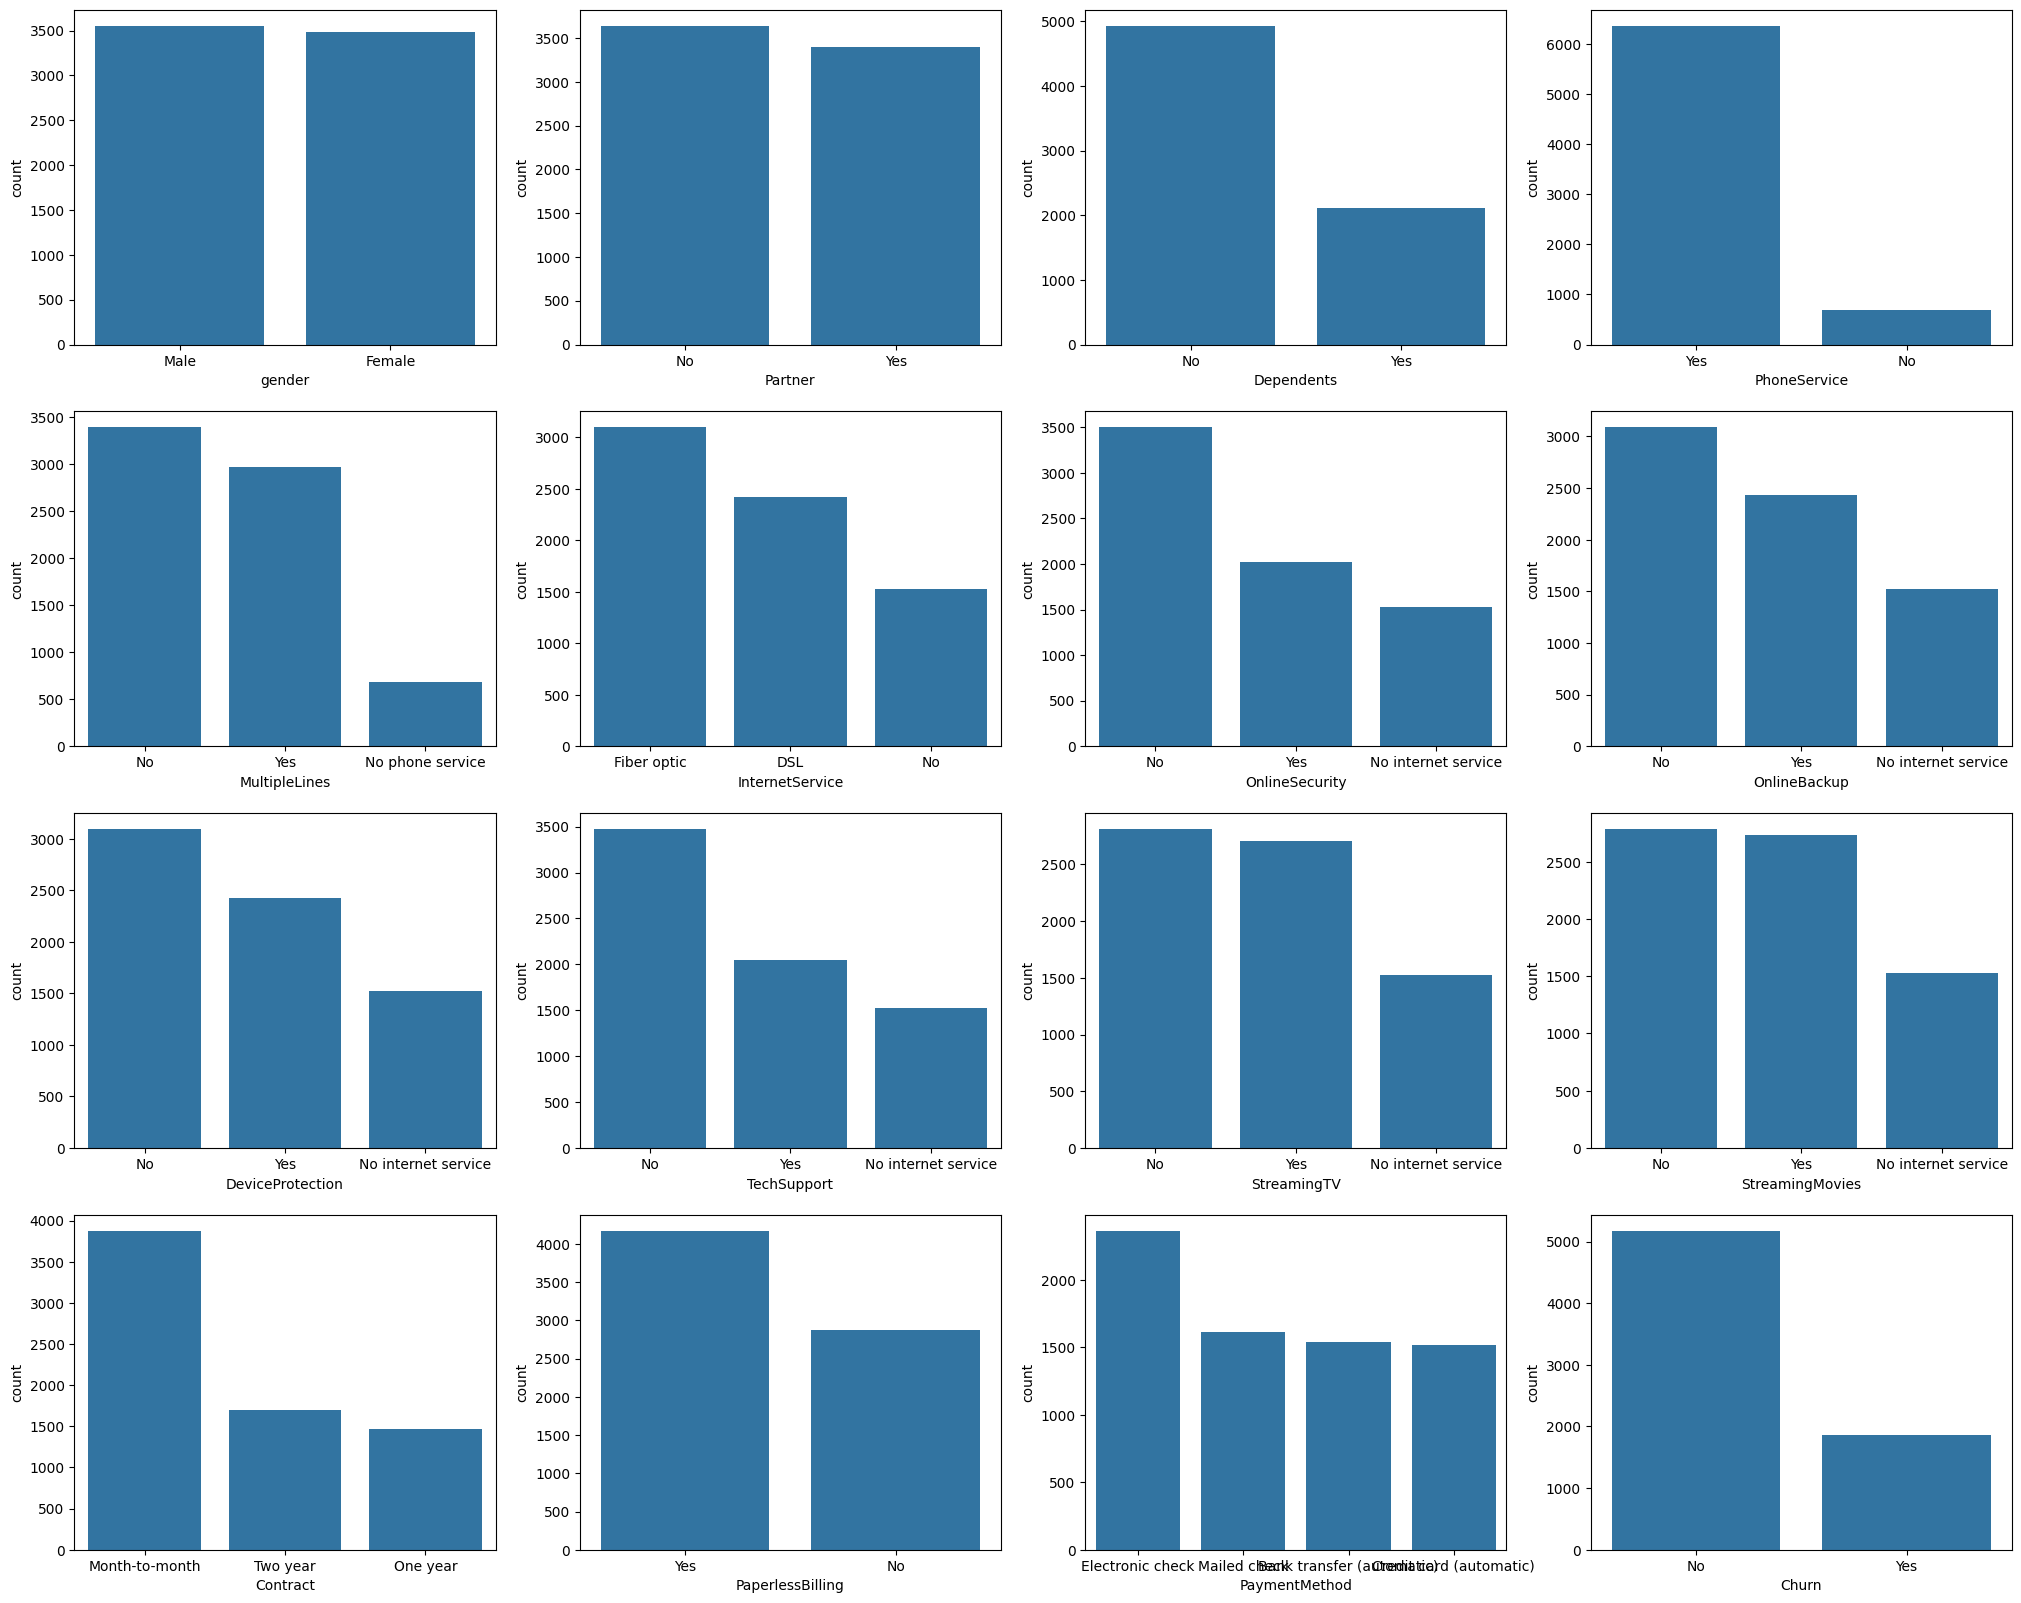

In [ ]:
for var in categorical:
    print(df[var].value_counts())

plt.figure(figsize=(25,20))
for i, var in enumerate(categorical):
    plt.subplot(4, 4, i+1)
    sns.barplot(df[var].value_counts())

### Cardinalidad

In [ ]:
for var in categorical:
    print(var, ' contiene ', len(df[var].unique()), ' valores diferentes')

gender  contiene  2  valores diferentes
Partner  contiene  2  valores diferentes
Dependents  contiene  2  valores diferentes
PhoneService  contiene  2  valores diferentes
MultipleLines  contiene  3  valores diferentes
InternetService  contiene  3  valores diferentes
OnlineSecurity  contiene  3  valores diferentes
OnlineBackup  contiene  3  valores diferentes
DeviceProtection  contiene  3  valores diferentes
TechSupport  contiene  3  valores diferentes
StreamingTV  contiene  3  valores diferentes
StreamingMovies  contiene  3  valores diferentes
Contract  contiene  3  valores diferentes
PaperlessBilling  contiene  2  valores diferentes
PaymentMethod  contiene  4  valores diferentes
Churn  contiene  2  valores diferentes



- **Gender, Partner, Dependents, PhoneService y PaperlessBilling** son binarias.
- **MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, Techsupport, StreamingTV y StreamingMovies** tienen como valores Yes, No o No internet service.
-  **InternetService, Contract, y PaymentMethod** tienen varias categorias.

### Explorar ``InternetService``

In [ ]:
df['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2421
No,1526


3096 clientes tienen fibra óptica, 2421 tienen DSL y 1526 no tienen ninguna de las dos.

### Explorar la variable ``Contract``

In [ ]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


3875 clientes tienen un contrato mensual, 1695 anual y 1473 cada dos años.

### Explorar la variable ``PaymentMethod``

In [ ]:
df['PaymentMethod'].value_counts()

,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


2365 clientes pagan mediante cheque electrónico, 1612 mediante cheque enviado por correo, 1544 mediante transferencia bancaria y 1522 mediante tarjeta de crédito.

## 3.4 Explorar las variables numéricas

In [ ]:
df[numerical].head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65


SeniorCitizen es binaria, el resto son continuas.

In [ ]:
df['SeniorCitizen'].value_counts()

,count
SeniorCitizen,
0,5901
1,1142


5901 clientes tienen menos de 65 años y 1142 más de 65 años.

### Valores faltantes

In [ ]:
df[numerical].isnull().sum()

,0
SeniorCitizen,0
tenure,0
MonthlyCharges,0
TotalCharges,11


Existen 11 valores faltantes en la variable "TotalCharges".

### Valor atípicos

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


<Axes: ylabel='TotalCharges'>

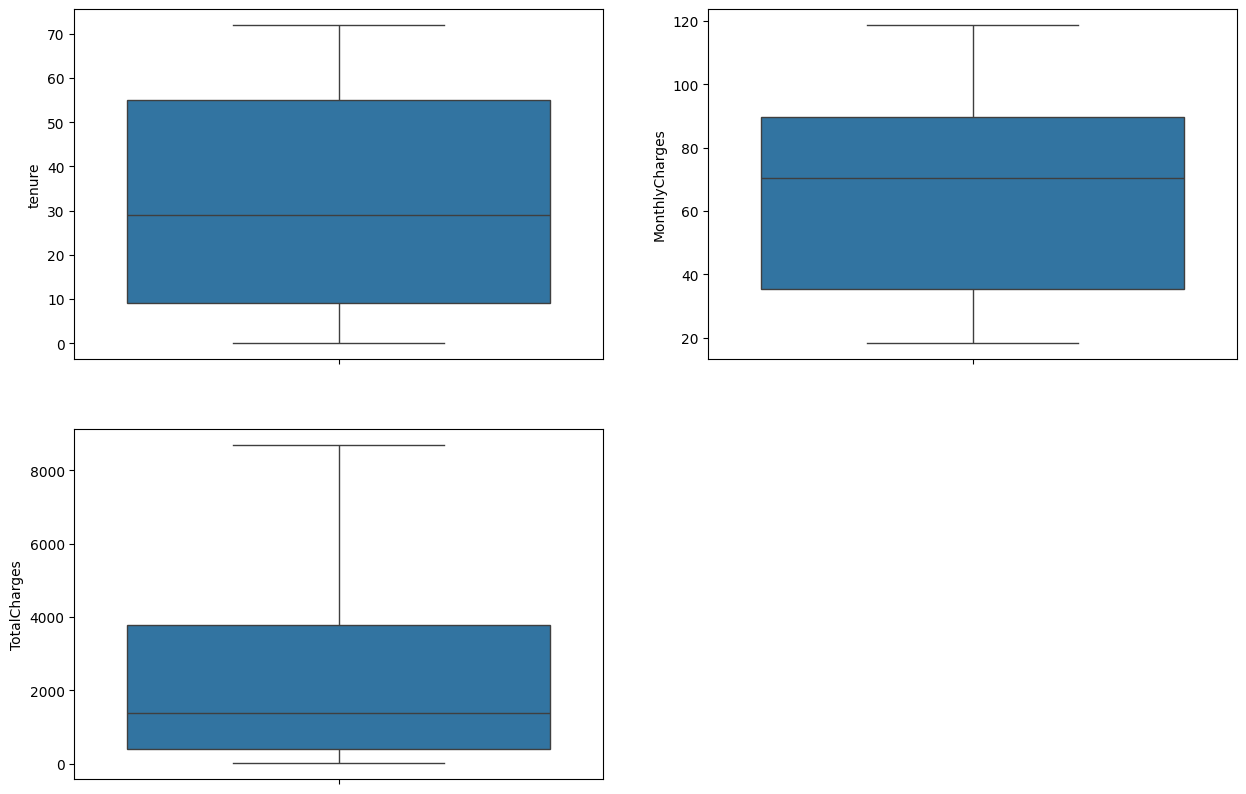

In [ ]:
plt.figure(figsize=(15,10))

plt.subplot(2, 2, 1)
sns.boxplot(df['tenure'])

plt.subplot(2, 2, 2)
sns.boxplot(df['MonthlyCharges'])

plt.subplot(2, 2, 3)
sns.boxplot(df['TotalCharges'])

Las variables numericas no muestran valores atípicos según el rango intercuartílico.

### Correlación

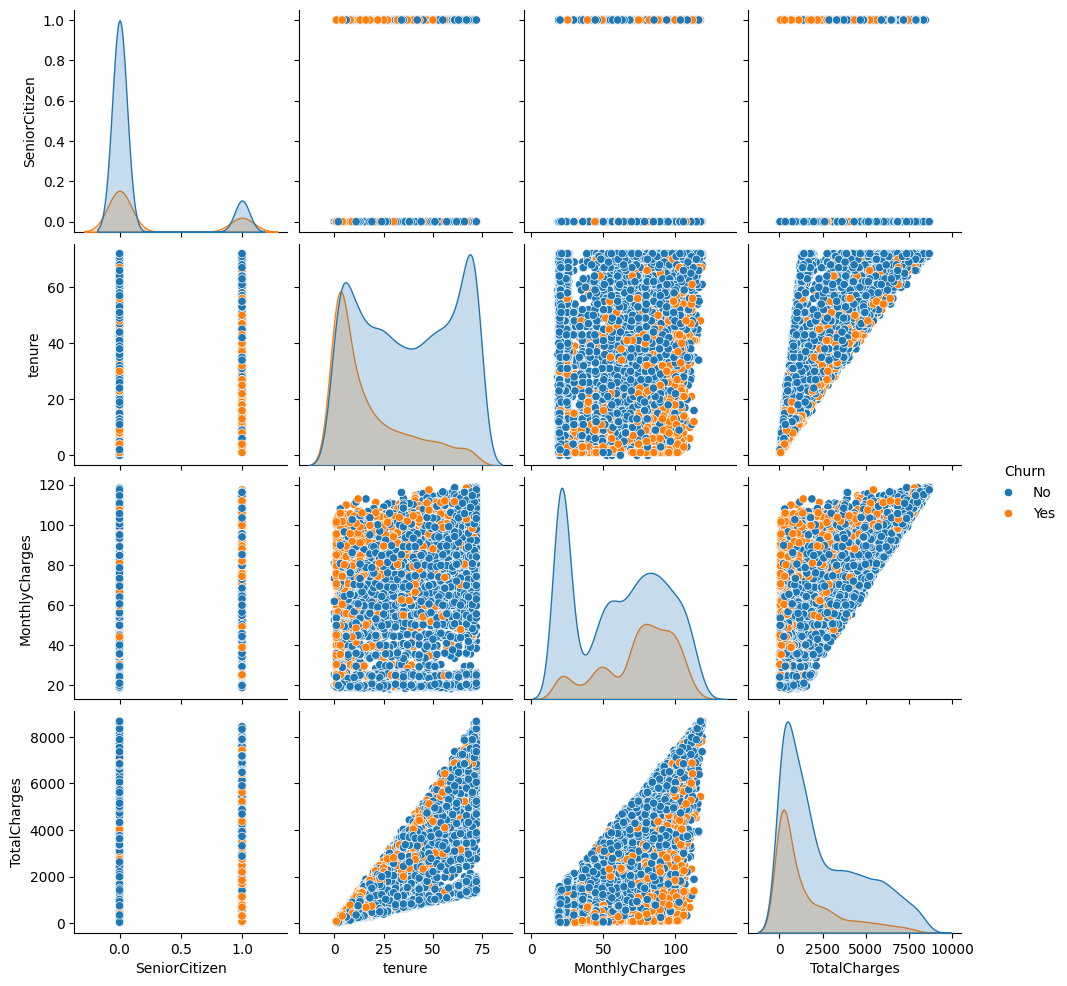

In [ ]:
sns.pairplot(df, hue='Churn')

<Axes: >

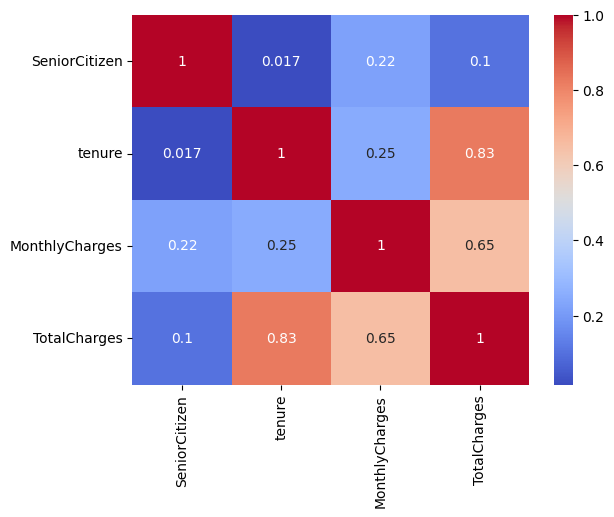

In [ ]:
sns.heatmap(df[numerical].corr(), annot=True, cmap='coolwarm')

La variables **tenure** y **TotalCharges** estan altamente correlacionadas, lo que tiene sentido ya que tenure indica la cantidad total de meses que lleva el cliente en la compañia mientras **TotalCharges** la cantidad total que ha pagado el cliente a la compañia desde que se dio de alta. Por tanto, cuantos más meses lleve el cliente más habrá pagado.  

Por otro lado, **MonthlyCharges** (lo que paga el cliente mensualmente) también esta relacionada con **TotalCharges**, lo que tiene sentido ya que **MonthlyCharges** forma parte de como se calcula **TotalCharges**. El total pagado por el cliente se calcula multiplicando lo que paga mensualmente por los meses que lleva en la compañia el cliente.

Voy a utilizar algoritmos que no se ven afectados por la correlación, por tanto mantendré las 3 variables.

### Distribución de las variables

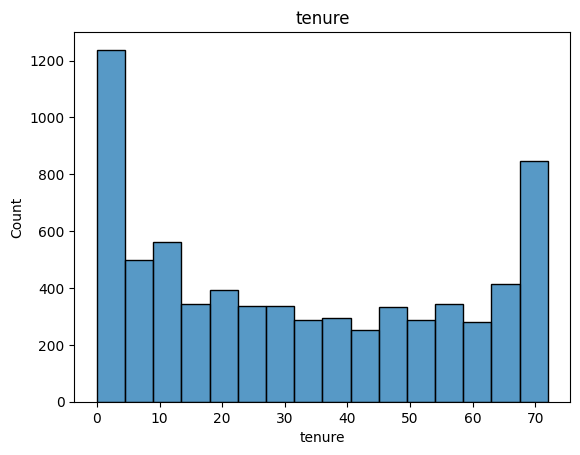

In [ ]:
sns.histplot(df['tenure'])
plt.title('tenure')
plt.show()


El pico de clientes la izquierda representa a los clientes nuevos. El pico de la derecha representa a los clientes con mayor antiguedad.

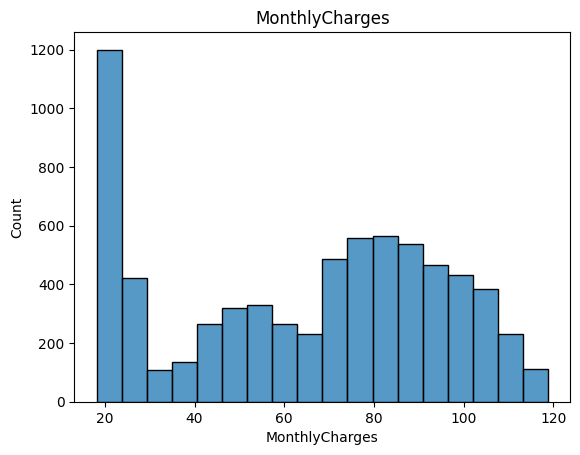

In [ ]:
sns.histplot(df['MonthlyCharges'])
plt.title('MonthlyCharges')
plt.show()

El pico de la izquierda representa a los clientes que tienen un cargo mensual bajo, con la tarifa más básica. Tiene varios picos intermedios que representan combinaciones de servicios que sean comunes.

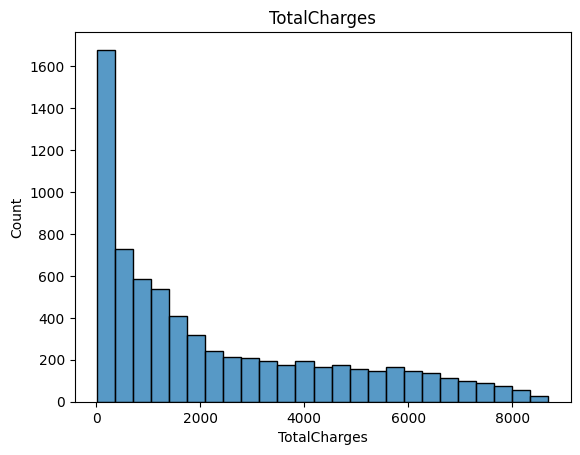

In [ ]:
sns.histplot(df['TotalCharges'])
plt.title('TotalCharges')
plt.show()

Esta distribución esta claramente sesgada hacia la derecha, hay un predominio de clientes nuevos.

Como ninguna variable sigue la distribución normal. Se utilizará la mediana en lugar de la media para tratar los valores faltantes más adelante.

## 3.5 Valores duplicados

In [ ]:
df.duplicated().sum()

np.int64(22)

Hay 22 registros duplicados.

In [ ]:
df.drop_duplicates(inplace=True)

# **4. Declarar X e y**

In [ ]:
X = df.drop(columns=['Churn'])
y = df['Churn']

# **5. Dividir datos en conjunto de entrenamiento y test**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Se utiliza stratify = y para asegurar que haya la misma proporción de y en los conjuntos de train y test.

In [ ]:
y_train.value_counts()/len(y_train)

,count
Churn,
No,0.735577
Yes,0.264423


In [ ]:
y_test.value_counts()/len(y_test)

,count
Churn,
No,0.735231
Yes,0.264769


# **6. Feature Engineering**

## 6.1 Ingeniería de valores faltantes en las variables numéricas

Se asume que los datos faltantes son completamente aleatorios. Al no existir valores atípicos en los datos, se imputaran los valores faltantes por la mediana.

La imputación se realizará sobre el conjunto de entrenamiento y luego se propagará al conjunto de test. Esto significa que la mediana que se usará para llenar los valores faltantes, tanto en el conjunto de entrenamiento como en el de prueba, se extrae  del conjunto de entrenamiento. Esto es para evitar el sobreajuste (overfitting).

In [ ]:
for df1 in [X_train, X_test]:
    median=X_train['TotalCharges'].median()
    df1['TotalCharges'].fillna(median, inplace=True)

In [ ]:
X_train.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
X_test.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


## 6.2 Encode de variables categoricas

En este apartado voy a transformar las variables categoricas en numéricas utilizando one-hot-encoding y transformando las variables de Yes/No en 0 y 1.

In [ ]:
categorical.remove('Churn')

In [ ]:
binarias = ['Partner', 'Dependents', 'PhoneService' ,'PaperlessBilling']
for var in binarias:
    categorical.remove(var)

In [ ]:
X_train[categorical].head()

,gender,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod
2629,Male,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Credit card (automatic)
2650,Female,Yes,Fiber optic,Yes,No,Yes,No,No,No,Month-to-month,Credit card (automatic)
1418,Male,Yes,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Bank transfer (automatic)
5774,Male,No,DSL,No,Yes,No,Yes,No,Yes,Month-to-month,Bank transfer (automatic)
2425,Male,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Electronic check


In [ ]:
X_train[binarias].head()

,Partner,Dependents,PhoneService,PaperlessBilling
2629,No,No,Yes,No
2650,No,No,Yes,Yes
1418,Yes,Yes,Yes,Yes
5774,No,No,Yes,Yes
2425,No,No,Yes,Yes


In [ ]:
mapping = {"No":0,'Yes':1}
for var in binarias:
    X_train[var] = X_train[var].map(mapping).fillna(0)
    X_test[var] = X_test[var].map(mapping).fillna(0)

y_train = y_train.map(mapping)
y_test = y_test.map(mapping)

In [ ]:
X_train[binarias].head()

,Partner,Dependents,PhoneService,PaperlessBilling
2629,0,0,1,0
2650,0,0,1,1
1418,1,1,1,1
5774,0,0,1,1
2425,0,0,1,1


In [ ]:
pd.get_dummies(X_train[categorical],drop_first=True).head().astype(int)

,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2629,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2650,0,0,1,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1418,1,0,1,1,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
5774,1,0,0,0,0,0,0,0,1,0,...,1,0,0,0,1,0,0,0,0,0
2425,1,0,0,0,1,1,0,1,0,1,...,0,1,0,1,0,0,0,0,1,0


In [ ]:
X_train = pd.concat([X_train[numerical],X_train[binarias],
                    pd.get_dummies(X_train['gender'],drop_first=True).astype(int),
                    pd.get_dummies(X_train['MultipleLines'],drop_first=True,prefix='MultipleLines').astype(int),
                    pd.get_dummies(X_train['InternetService'],drop_first=True, prefix='InternetService').astype(int),
                    pd.get_dummies(X_train['OnlineSecurity'],drop_first=True,prefix='OnlineSecurity').astype(int),
                    pd.get_dummies(X_train['OnlineBackup'],drop_first=True,prefix='OnlineBackup').astype(int),
                    pd.get_dummies(X_train['DeviceProtection'],drop_first=True,prefix='DeviceProtection').astype(int),
                    pd.get_dummies(X_train['TechSupport'],drop_first=True,prefix='TechSupport').astype(int),
                    pd.get_dummies(X_train['StreamingTV'],drop_first=True,prefix='StreamingTV').astype(int),
                    pd.get_dummies(X_train['StreamingMovies'],drop_first=True,prefix='StreamingMovies').astype(int),
                    pd.get_dummies(X_train['Contract'],drop_first=True, prefix='Contract').astype(int),
                    pd.get_dummies(X_train['PaymentMethod'],drop_first=True, prefix='PaymentMethod').astype(int)], axis=1
                    )
X_test = pd.concat([X_test[numerical],X_test[binarias],
                    pd.get_dummies(X_test['gender'],drop_first=True).astype(int),
                    pd.get_dummies(X_test['MultipleLines'],drop_first=True,prefix='MultipleLines').astype(int),
                    pd.get_dummies(X_test['InternetService'],drop_first=True,prefix='InternetService').astype(int),
                    pd.get_dummies(X_test['OnlineSecurity'],drop_first=True,prefix='OnlineSecurity').astype(int),
                    pd.get_dummies(X_test['OnlineBackup'],drop_first=True,prefix='OnlineBackup').astype(int),
                    pd.get_dummies(X_test['DeviceProtection'],drop_first=True,prefix='DeviceProtection').astype(int),
                    pd.get_dummies(X_test['TechSupport'],drop_first=True,prefix='TechSupport').astype(int),
                    pd.get_dummies(X_test['StreamingTV'],drop_first=True,prefix='StreamingTV').astype(int),
                    pd.get_dummies(X_test['StreamingMovies'],drop_first=True,prefix='StreamingMovies').astype(int),
                    pd.get_dummies(X_test['Contract'],drop_first=True,prefix='Contract').astype(int),
                    pd.get_dummies(X_test['PaymentMethod'],drop_first=True,prefix='PaymentMethod').astype(int)], axis=1
                    )

In [ ]:
X_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Partner,Dependents,PhoneService,PaperlessBilling,Male,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2629,0,2,70.70,140.70,0,0,1,0,1,0,...,0,0,0,0,0,0,0,1,0,0
2650,0,15,84.35,1302.65,0,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
1418,0,67,89.55,6373.10,1,1,1,1,1,0,...,0,0,0,0,1,0,0,0,0,0
5774,0,5,65.60,339.90,0,0,1,1,1,0,...,1,0,0,0,1,0,0,0,0,0
2425,0,26,20.30,511.25,0,0,1,1,1,0,...,0,1,0,1,0,0,0,0,1,0


## 6.3 Feature Scaling

Voy a escalar los datos con MinMaxScaler ya que las variables tienen magnitudes muy diferentes y las variables con escalas más grandes que otras tendrian más importancia para los modelos.

In [ ]:
cols = X_train.columns

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train = pd.DataFrame(X_train, columns=cols)
X_test = pd.DataFrame(X_test, columns=cols)

In [ ]:
X_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Partner,Dependents,PhoneService,PaperlessBilling,Male,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0.027778,0.521891,0.014061,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.208333,0.657711,0.148143,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.930556,0.709453,0.733243,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.069444,0.471144,0.037047,0.0,0.0,1.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.361111,0.020398,0.056820,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


# **7. Entrenamiento de modelos**

In [ ]:
import scipy as sp
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import sklearn.metrics as metrics
from sklearn.metrics import confusion_matrix, accuracy_score

Voy a entrenar 3 modelos: K-Neighbors, Random Forest y Xgboost.

## 7.1 K-Nearest Neighbors

In [ ]:
knn = KNeighborsClassifier()

param_grid = {'n_neighbors':sp.stats.randint(1, 20),
              'weights': ['uniform', 'distance'],
              'leaf_size':sp.stats.randint(1, 10),
              'algorithm':['auto', 'kd_tree','ball_tree','brute'],
              'metric': ['minkowski','euclidean','manhattan','chebyshev']}

knn_model = RandomizedSearchCV(knn, param_grid,n_iter=100, random_state=0, cv=5, scoring='roc_auc')
knn_model.fit(X_train,y_train)

KeyboardInterrupt: 

He usado como métrica de puntuación en el random search ROC AUC en lugar del accuracy ya que el problema de clasificación de fuga de clientes esta desbalanceado y el accuracy puede ser engañoso, ya que puede ser alto simplemente prediciendo que ningun cliente se marcha. Por otro lado, ROC AUC mide la capacidad del modelo de diferenciar entre clientes que se marchan y clientes que se quedan, independientemente de la distribución de clase.  

### Accuracy

In [ ]:
y_pred_test = knn_model.predict(X_test)
y_pred_test_proba = knn_model.predict_proba(X_test)
y_pred_train = knn_model.predict(X_train)

print('Accuracy train: ',metrics.accuracy_score(y_train, y_pred_train))
print('Accuracy test: ', metrics.accuracy_score(y_test, y_pred_test))

El accuracy en train y test es similar por tanto no se produce overfitting.

In [ ]:
print("Best parameters "+str(knn_model.best_params_))

### Matriz de confusión

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_estimator(
    knn_model,
    X_test,
    y_test,
    cmap=plt.cm.Blues,
    values_format='.0f',
    ax=ax
)
plt.show()

El modelo genera 189 falsos negativos, 117 falsos positivos, 916 verdaderos negativos y 183 verdaderos positivos.

In [ ]:
print(confusion_matrix(y_test,y_pred_test))

### Reporte de clasificación

In [ ]:
pd.DataFrame(classification_report(y_test,y_pred_test, output_dict=True)).T

El modelo tiene una sensibilidad de la clase positiva del 49% (de los que se marchan, predice bien al 49%) y una precisión del 61% (de los que predice como 1, acierta un 61% de veces).

### ROC AUC

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test_proba[:, 1])

# Calculate AUC
roc_auc = auc(fpr, tpr)

print(f"AUC para knn: {roc_auc:.4f}")

# Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

El modelo funciona bien discriminando entre clases.

## 7.2 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()

param_grid = {"n_estimators": [100,150],
              'criterion':['gini','entropy','log_loss'],
              'max_depth': [sp.stats.randint(1, 20),None],
              'min_samples_split': sp.stats.randint(1, 15),
              'min_samples_leaf':sp.stats.randint(1, 15),
              'max_features': ['sqrt', 'log2', None],
              'oob_score': [True],
              'class_weight': ['balanced','balanced_subsample',None]
              }
rfc_model = RandomizedSearchCV(rfc,param_grid,n_iter=100,cv=5, scoring='roc_auc')
rfc_model.fit(X_train,y_train)

### Accuracy

In [ ]:
y_pred_train = rfc_model.predict(X_train)
y_pred_test = rfc_model.predict(X_test)
print('Accuracy train: ',metrics.accuracy_score(y_train, y_pred_train))
print('Accuracy test: ', metrics.accuracy_score(y_test, y_pred_test))
print("Best parameters "+str(rfc_model.best_params_))

El accuracy en train y test es similar por tanto no se produce overfitting.

In [ ]:
rfc_model.best_estimator_.oob_score_

El oob score mide el rendimiento del modelo evaluando con las muestras que no fueron seleccionadas en cada arbol individual.

### Matriz de confusión

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_estimator(
    rfc_model,
    X_test,
    y_test,
    cmap=plt.cm.Blues,
    values_format='.0f',
    ax=ax
)
plt.show()

Hay 92 falsos negativos, 233 falsos positivos, 800 verdaderos negativos y 280 verdaderos positivos.

### Reporte de clasificación

In [ ]:
pd.DataFrame(classification_report(y_test,y_pred_test, output_dict=True)).T

El modelo tiene una sensibilidad de la clase positiva del 75% y una precisión del 55%

### AUC and ROC

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC
y_pred_test_proba = rfc_model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test_proba[:, 1])

# Calculate AUC
roc_auc = auc(fpr, tpr)

print(f"AUC para Random Forest: {roc_auc:.4f}")

# Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

El modelo funciona bien discriminando entre clases.

## 7.3 Xgboost

In [ ]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
scale_pos_weight

np.float64(2.7818181818181817)

In [ ]:
import xgboost as xgb

neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

xgboost = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

param_grid = {
    "n_estimators": sp.stats.randint(50, 500),
    "max_depth": sp.stats.randint(3, 10),
    "learning_rate": sp.stats.uniform(0.01, 0.3),
    "subsample": sp.stats.uniform(0.6, 0.4),
    "colsample_bytree": sp.stats.uniform(0.6, 0.4),
    "gamma": sp.stats.uniform(0, 5),
    "reg_alpha": sp.stats.uniform(0, 5),
    "reg_lambda": sp.stats.uniform(0, 5)
}


xgb_model = RandomizedSearchCV(xgboost,param_grid,n_iter=100,cv=5, scoring='roc_auc')

xgb_model.fit(X_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='auc',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrai...
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b3699e83d10>,
                                        'reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b3699d32150>,
                                        'reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b3699e11e50>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b3699c7f980>},
                   scoring='roc_auc')

### Accuracy

In [ ]:
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)
y_pred_test_proba = xgb_model.predict_proba(X_test)

print('Accuracy train: ',metrics.accuracy_score(y_train, y_pred_train))
print('Accuracy test: ', metrics.accuracy_score(y_test, y_pred_test))
print("Best parameters "+str(xgb_model.best_params_))

Accuracy train:  0.7717236467236467
Accuracy test:  0.7530249110320285
Best parameters {'colsample_bytree': np.float64(0.8061500348458109), 'gamma': np.float64(4.279309543352588), 'learning_rate': np.float64(0.1187380446313745), 'max_depth': 4, 'n_estimators': 104, 'reg_alpha': np.float64(4.497317464604528), 'reg_lambda': np.float64(2.4334628757934103), 'subsample': np.float64(0.6622726421919823)}


El accuracy en train y test es similar por tanto no se produce overfitting.

### Matriz de confusión

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(8,8))
ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test, cmap=plt.cm.Blues,values_format='.0f', ax=ax )

Hay 79 falsos negativos, 273 falsos positivos, 760 verdaderos negativos y 293 verdaderos positivos.

### Reporte de clasificación

In [ ]:
pd.DataFrame(classification_report(y_test,y_pred_test, output_dict=True)).T

El modelo tiene una sensibilidad de la clase positiva del 79% y una precisión del 52%.

### AUC and ROC

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test_proba[:, 1])

# Calculate AUC
roc_auc = auc(fpr, tpr)

print(f"AUC para Xgboost: {roc_auc:.4f}")

# Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

El modelo que mejor discrimina entre clases es el XGboost con un AUC ROC de 0.8428.

## Mejor umbral de decisión

En un problema de tasa de abandono de clientes, para una empresa es mucho más barato invertir en no perder un cliente que invertir en conseguir nuevos clientes. Por tanto el recall es la métrica más importante, no importa tanto los falsos positivos sino optimizar los falsos negativos. Por ello se va a decidir el umbral que optimice el F2 score (importa el doble recall frente precisión.)

In [ ]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_test,y_pred_test_proba[:,1])

# Calcular el F2-Score para cada umbral
# Formula F-Beta: (1 + beta^2) * (P * R) / ((beta^2 * P) + R)
beta = 2
numerator = (1 + beta**2) * (precisions * recalls)
denominator = (beta**2 * precisions) + recalls

# Evitar divisón por 0
f2_scores = np.divide(numerator, denominator, out=np.zeros_like(denominator), where=denominator!=0)

# Encontrar el índice del F2 más alto
ix = np.argmax(f2_scores[:-1])
best_thresh = thresholds[ix]
best_f2 = f2_scores[ix]

print(f"Mejor Threshold: {best_thresh:.4f}")
print(f"F2-Score máximo: {best_f2:.4f}")
print(f"Recall en este punto: {recalls[ix]:.4f}")
print(f"Precision en este punto: {precisions[ix]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f2_scores[:-1], label='F2 Score', color='green', linewidth=2)
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Óptimo: {best_thresh:.2f}')

plt.title('Evolución del F2-Score según el Threshold')
plt.xlabel('Threshold (Umbral de decisión)')
plt.ylabel('F2 Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
y_pred_final = (y_pred_test_proba[:, 1] >= best_thresh).astype(int)
pd.DataFrame(classification_report(y_test,y_pred_final, output_dict=True)).T


Con el umbral de 0.3915 se logra un recall del 87.63% con una precisión del 46.90%.

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final,cmap=plt.cm.Blues,values_format='.0f', ax=ax )

Hay 46 falsos negativos, 369 falsos positivos, 664 verdaderos negativos y 326 verdaderos positivos.

# **8. SHAP values**

Voy a calcular los valores SHAP del modelo XGBoost para ver que variables son más importantes en la predicción y para ver en que medida afectan a ella.

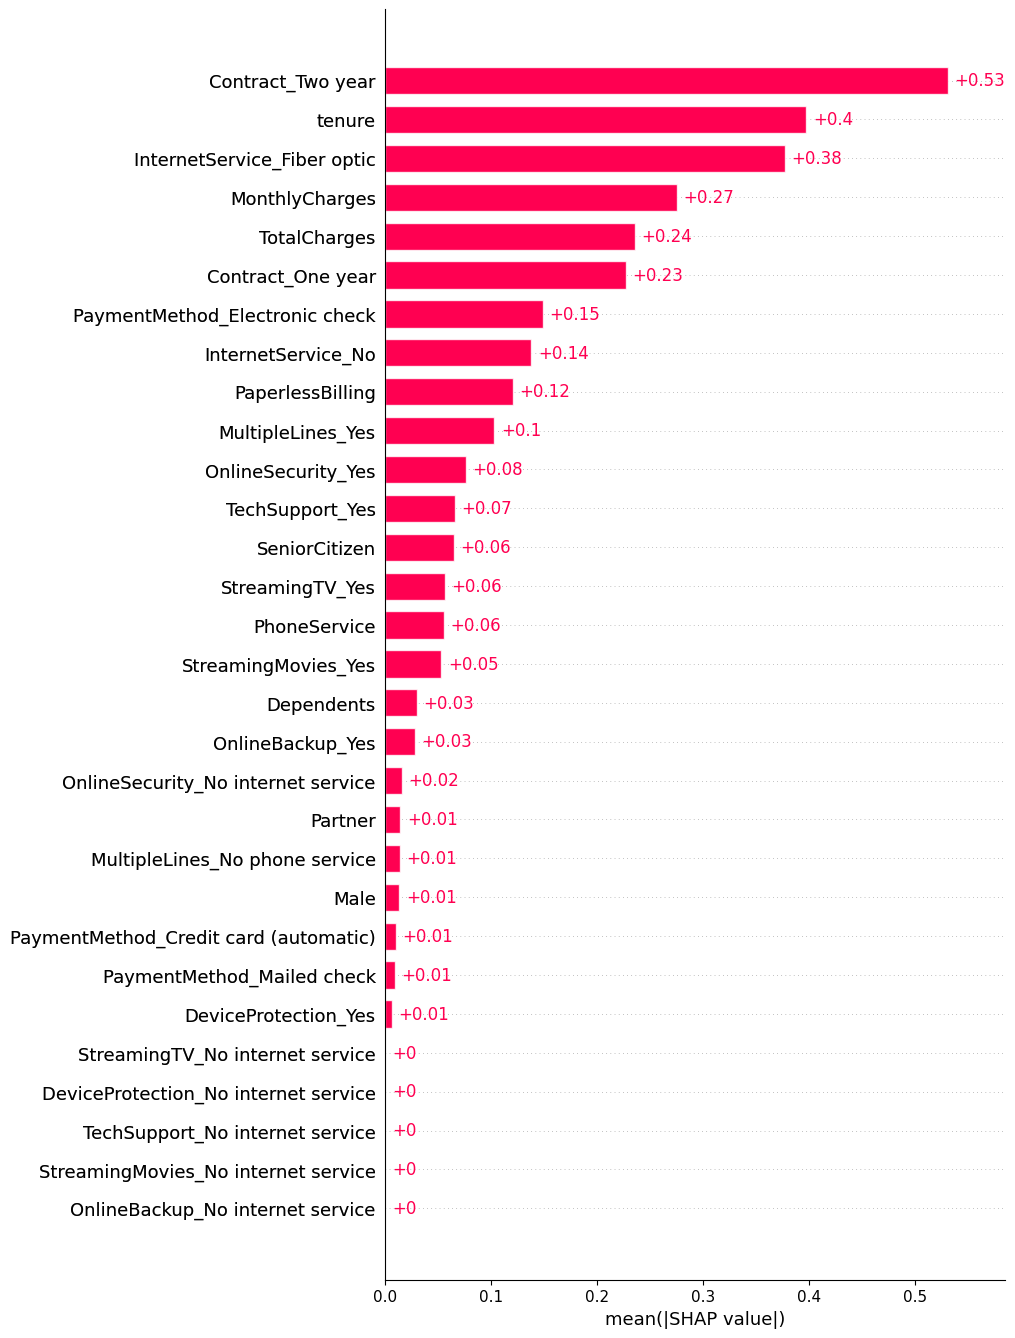

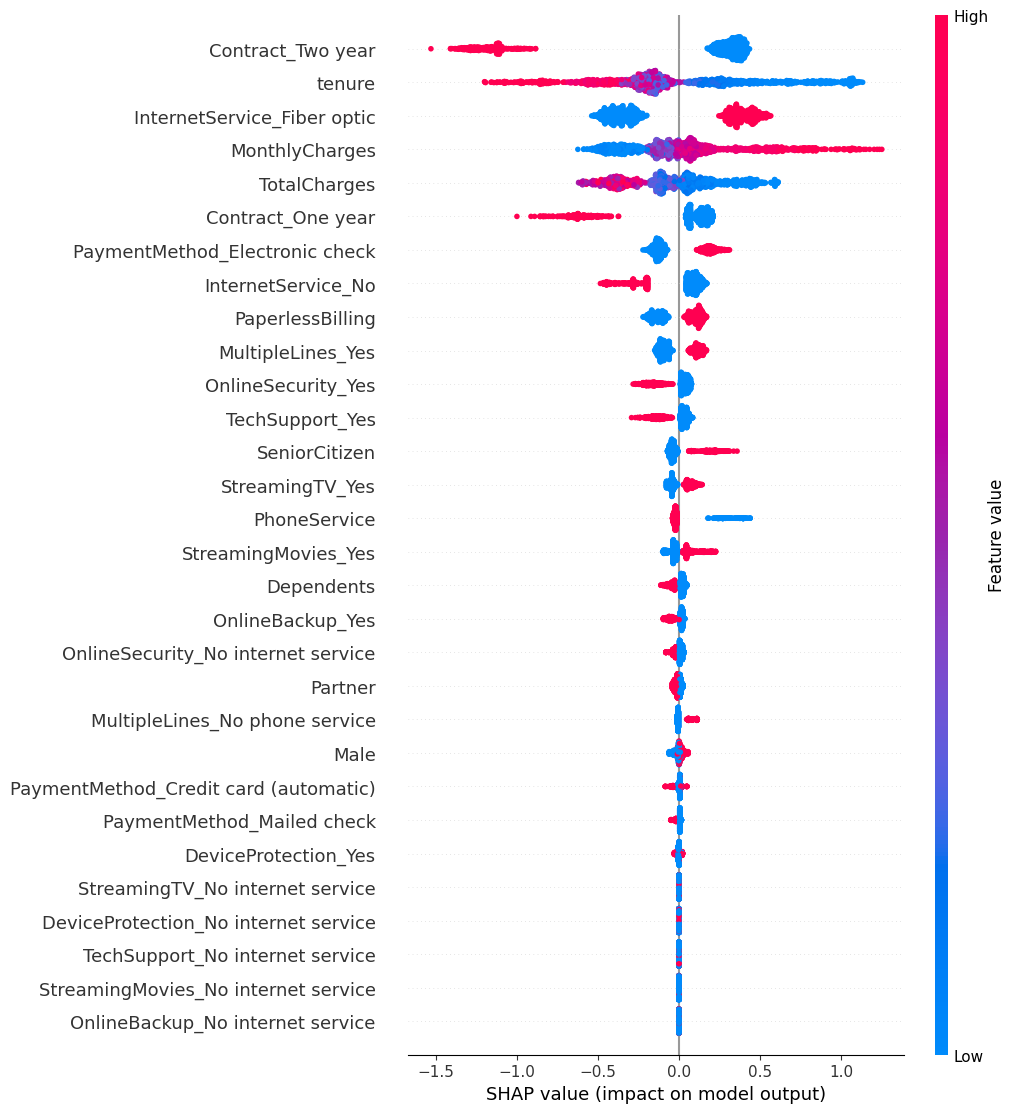

In [ ]:
import shap

# Estimator
est = xgb_model.best_estimator_

# Explainer
explainer = shap.TreeExplainer(est,X_train)
shap_vals = explainer(X_test)

shap.plots.bar(shap_vals, max_display=30)
shap.plots.beeswarm(shap_vals, max_display=30)

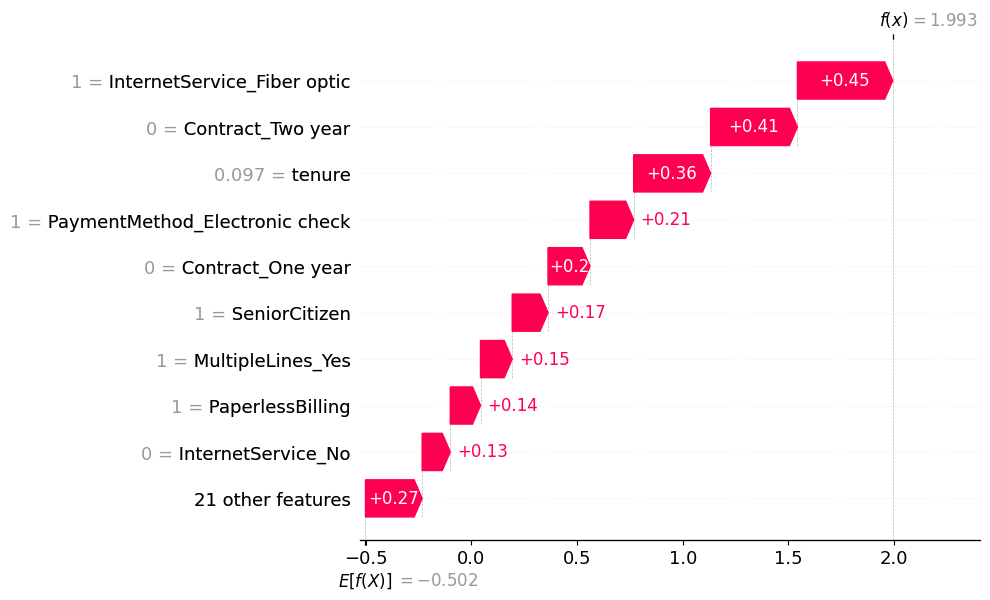

In [ ]:
shap.plots.waterfall(shap_vals[0])

Que el cliente tenga un contrato de dos años, la antiguedad del cliente y que el cliente tenga fibra óptica son las variables que más afectan a la predicción.  
En concreto, que un cliente tenga un contrato de dos años reduce la probabilidad de abandono, clientes con más tiempo en la compañia tienen menor probabilidad de abandono y clientes con fibra óptica tienen más probabilidad de abandono.

Variables más importantes que aumentan la probabilidad de abandono:
- Clientes con fibra óptica contratada
- Clientes con un cargo mensual elevado
- Clientes que pagan con un cheque electrónico
- Clientes que piden la factura sin papel
- Clientes que tienen varias lineas
- Clientes que utilizan un proveedor externo para el servicio de streaming de películas

# Deploy del modelo con docker

In [ ]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# 1. Cargar Datos
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. Limpieza Básica
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df = df.drop(columns=['customerID'])
df.drop_duplicates(inplace=True)

# 3. Separar X e y
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. Definir tipo de columna
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()

# 5. Crear el Preprocesador

# Preprocesador numerico
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# Preprocesador categórico
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# 6. Modelo final
neg, pos = np.bincount(y)
scale_pos_weight = neg / pos

model_params = {
    'n_estimators': 232,
    'max_depth': 3,
    'learning_rate': 0.0336,
    'subsample': 0.667,
    'colsample_bytree': 0.789,
    'gamma': 1.848,
    'reg_alpha': 3.543,
    'reg_lambda': 3.676,
    'scale_pos_weight': scale_pos_weight,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'use_label_encoder': False,
    'random_state': 42
}

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(**model_params))
])

# 7. Entrenar y guardar
pipeline.fit(X,y)
joblib.dump(pipeline, 'churn_pipeline.pkl')

['churn_pipeline.pkl']